In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

import sys


from pyS3M import IOFunctions

IO = IOFunctions.IO_Functions()

from pyS3M import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from pyS3M import PlottingBase

plotter = PlottingBase.PublicationPlotter()

from pyS3M import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from pyS3M import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from pyS3M import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from pyS3M import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from pyS3M import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from pyS3M import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from pyS3M import SR_Functions

SupRes_F = SR_Functions.SuperRes_Functions()

from jupyter_bbox_widget import BBoxWidget
import ipywidgets as widgets
from io import BytesIO
from PIL import Image
import pyS3M.HelperFunctions as HelperFunctions

H_F = HelperFunctions.Helper_Functions()

INFO:Constants:Logging to file: /home/jsb92/Documents/pyBayerSMLM/logs/Constants_20260218_082757.log
/tmp/ipykernel_760152/3538909434.py:25: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter()


In [2]:
data_folder = "../../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [3]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [4]:
image_folder = "/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/HeLaCellSTORM/20250523_HeLa_STORM/Cell4_HILO_190mW_638_ximea638_setting/Lp638_190_mw_40ms_exosure_HILO_1"
image_files = H_F.file_search(image_folder, ".tif", "")

/home/jsb92/Documents/pyBayerSMLM/notebooks/hela_tubulin/../../src/SR_Functions.py:995: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


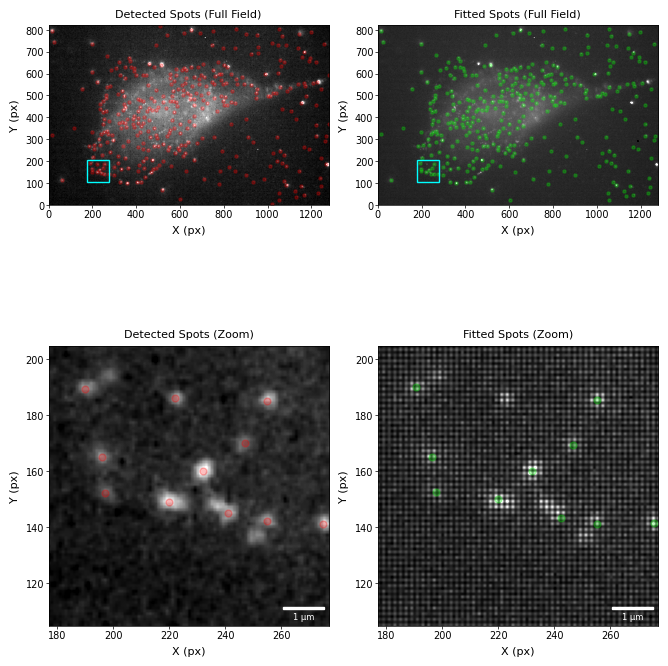

In [5]:
# play around with pfa to find a good parameter
pfa = 1e-4
sigma = 1.5
fraction_true=0.2
peak_wavelength = 0.7
frame_index = 10
fig, axs = SupRes_F.example_spots_singleframe(image_folder, pfa=pfa, sigma=sigma, fraction_true=fraction_true, 
                                              frame_index=frame_index, variance=variance, read_noise=read_noise,
                                             rqe=rqe, offset_map=offset_map, gain_map=gain_map, peak_wavelength=peak_wavelength)
plt.show()

In [6]:
SupRes_F.fit_imaging_data(
    image_folder,
    smoothing_function,
    gain_map,
    offset_map,
    rqe,
    read_noise,
    variance=variance,
    pfa=pfa,
    ROI_size=12,
    peak_wavelength=peak_wavelength,
    fraction_true=fraction_true,
    sigma=sigma,
    NA=1.49,
    pixel_size=0.069,
    image_type=".tif",
)

Processing file 1/25: 2012 frames in chunks of 1000
  Processing chunk: frames 0-999
  Processing chunk: frames 1000-1999                                            ?, ?it/s]
  Processing chunk: frames 2000-2011                                            ?, ?it/s]
  Found 441719 puncta across all chunks                                         ?, ?it/s]
Processing file 2/25: 2012 frames in chunks of 1000                             ?, ?it/s]
  Processing chunk: frames 0-999
  Processing chunk: frames 1000-1999                                            ?, ?it/s]
  Processing chunk: frames 2000-2011                                            ?, ?it/s]
  Found 327719 puncta across all chunks                                         ?, ?it/s]
Sorting appended HDF5 file by frame: Localisations.h5                           ?, ?it/s]
  Read 186,730 total localizations
  Sorted by frame (range: 0-4023)
  Rewritten sorted data to Localisations.h5
Processing file 3/25: 2012 frames in chunks of 10

In [7]:
image_folder = "/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/HeLaCellSTORM/20250523_HeLa_STORM/Cell3_HILO_190mW_638_ximea638_setting/Lp638_190_mw_40ms_exosure_HILO_1"
SupRes_F.fit_imaging_data(
    image_folder,
    smoothing_function,
    gain_map,
    offset_map,
    rqe,
    read_noise,
    variance=variance,
    pfa=pfa,
    ROI_size=12,
    peak_wavelength=peak_wavelength,
    fraction_true=fraction_true,
    sigma=sigma,
    NA=1.49,
    pixel_size=0.069,
    image_type=".tif",
)

Processing file 1/29: 1750 frames in chunks of 1000
  Processing chunk: frames 0-999
  Processing chunk: frames 1000-1749                                            ?, ?it/s]
  Found 245096 puncta across all chunks                                         ?, ?it/s]
Processing file 2/29: 1750 frames in chunks of 1000                             ?, ?it/s]
  Processing chunk: frames 0-999
  Processing chunk: frames 1000-1749                                            ?, ?it/s]
  Found 220085 puncta across all chunks                                         ?, ?it/s]
Sorting appended HDF5 file by frame: Localisations.h5                           ?, ?it/s]
  Read 85,505 total localizations
  Sorted by frame (range: 0-3499)
  Rewritten sorted data to Localisations.h5
Processing file 3/29: 1750 frames in chunks of 1000
  Processing chunk: frames 0-999
  Processing chunk: frames 1000-1749                                            ?, ?it/s]
  Found 199986 puncta across all chunks                

In [8]:
image_folder = "/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/HeLaCellSTORM/20250523_HeLa_STORM/Cell2_HILO_190mW_638_ximea638_setting/Lp638_190_mw_40ms_exosure_HILO_1"
SupRes_F.fit_imaging_data(
    image_folder,
    smoothing_function,
    gain_map,
    offset_map,
    rqe,
    read_noise,
    variance=variance,
    pfa=pfa,
    ROI_size=12,
    peak_wavelength=peak_wavelength,
    fraction_true=fraction_true,
    sigma=sigma,
    NA=1.49,
    pixel_size=0.069,
    image_type=".tif",
)

Processing file 1/75: 669 frames in chunks of 1000
  Processing chunk: frames 0-668
  Found 228011 puncta across all chunks                                         ?, ?it/s]
Processing file 2/75: 669 frames in chunks of 1000                              ?, ?it/s]
  Processing chunk: frames 0-668
  Found 201861 puncta across all chunks                                         ?, ?it/s]
Sorting appended HDF5 file by frame: Localisations.h5                           ?, ?it/s]
  Read 64,555 total localizations
  Sorted by frame (range: 0-1337)
  Rewritten sorted data to Localisations.h5
Processing file 3/75: 669 frames in chunks of 1000
  Processing chunk: frames 0-668
  Found 187008 puncta across all chunks                                         ?, ?it/s]
Sorting appended HDF5 file by frame: Localisations.h5                           ?, ?it/s]
  Read 92,548 total localizations
  Sorted by frame (range: 0-2006)
  Rewritten sorted data to Localisations.h5
Processing file 4/75: 669 frames in

In [9]:
image_folder = "/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/HeLaCellSTORM/20250523_HeLa_STORM/Cell1_HILO_190mW_638_ximea638_setting/Lp638_190_mw_40ms_exosure_HILO_2"
SupRes_F.fit_imaging_data(
    image_folder,
    smoothing_function,
    gain_map,
    offset_map,
    rqe,
    read_noise,
    variance=variance,
    pfa=pfa,
    ROI_size=12,
    peak_wavelength=peak_wavelength,
    fraction_true=fraction_true,
    sigma=sigma,
    NA=1.49,
    pixel_size=0.069,
    image_type=".tif",
)

Processing file 1/18: 2923 frames in chunks of 1000
  Processing chunk: frames 0-999
  Processing chunk: frames 1000-1999                                            ?, ?it/s]
  Processing chunk: frames 2000-2922                                            ?, ?it/s]
  Found 45547 puncta across all chunks                                          ?, ?it/s]
Processing file 2/18: 2923 frames in chunks of 1000                             ?, ?it/s]
  Processing chunk: frames 0-999
  Processing chunk: frames 1000-1999                                            ?, ?it/s]
  Processing chunk: frames 2000-2922                                            ?, ?it/s]
  Found 44234 puncta across all chunks                                          ?, ?it/s]
Sorting appended HDF5 file by frame: Localisations.h5                           ?, ?it/s]
  Read 8,889 total localizations
  Sorted by frame (range: 0-5845)
  Rewritten sorted data to Localisations.h5
Processing file 3/18: 2923 frames in chunks of 1000